In [1]:
library(car)
library(glmnet)
library(GGally)
library(ComplexHeatmap)
library(ggplotify)
library(caret)
library(pROC)
library(readxl)

Loading required package: carData

Loading required package: Matrix

Loaded glmnet 4.1-6

Loading required package: ggplot2

Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2

Loading required package: grid

ComplexHeatmap version 2.12.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Loading required package: lattice

Type 'citation("pROC")' for a

In [2]:
lipid_meta = read.csv('../data/var_importance.b1.csv')

In [16]:
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')

became_data = scaled_df[rownames(subset(meta,cohort=='BECAME')),]
became_meta = meta[rownames(became_data),]
became_data$response_var = as.factor(as.numeric(became_meta[rownames(became_data),'group']=='HFpEF'))


In [17]:
head(became_data)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,⋯,X153,X154,X155,X156,X157,X158,X159,X160,X161,response_var
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
X10299,-0.8846231,-0.2366197,-1.1346356,-1.4879802,-1.32083091,0.03917288,1.7193423,0.1777812,0.8454540,0.8377637,⋯,-0.87781520,-0.6001580,0.05438448,-1.2300569,-0.5817451,-0.22532238,-1.7948332,-0.51970962,-1.1199888,1
X10301,1.2298502,1.0083514,0.9910490,1.4484539,-1.12978061,-1.98345475,0.3388187,-0.9852176,1.0583726,0.1234801,⋯,0.01214166,-0.6901384,-0.20976688,-0.9165250,-0.2246247,1.18054222,-0.2700098,-0.63686176,-0.7675901,1
X10302,0.7082120,1.2017351,-0.1426653,-1.5282007,2.65792490,0.46690883,1.8133542,-1.1271570,0.6397249,0.2578685,⋯,-1.44644573,0.6895035,0.09252553,-1.1220756,-0.6448140,0.06001824,-1.8151585,1.50119945,-1.0466279,1
X10303,1.4585259,1.1553651,1.6476913,1.8326409,0.54123967,0.23416474,0.1287547,-2.2367297,0.7248176,1.0224270,⋯,0.58768795,-0.4122167,0.21457422,0.8997899,0.9886719,0.59776421,1.0061154,-0.02776119,-0.3347963,1
X10304,0.8790564,0.4628459,1.0550563,-0.8766916,0.57370132,-0.67048026,-0.1194122,0.7610332,-0.9722788,0.2549890,⋯,-0.99743744,1.2421471,1.22759381,0.5348494,-0.2334569,1.04773481,-0.8856914,0.97319752,1.1125621,1
X10305,0.5341307,0.4357803,0.2021826,1.6019929,0.07984628,-1.29835269,-0.8076673,0.3338979,-1.5592522,-3.3848118,⋯,-0.47104905,-1.3849628,-0.81925563,-1.3510289,2.3024361,0.65869288,0.4231444,-1.22865291,-0.2727916,1


Total Observations: 174 
Events: 102 
Predictors: 161 
EPV: 0.6335404 


Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Minimum VIF: 66.77856 


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


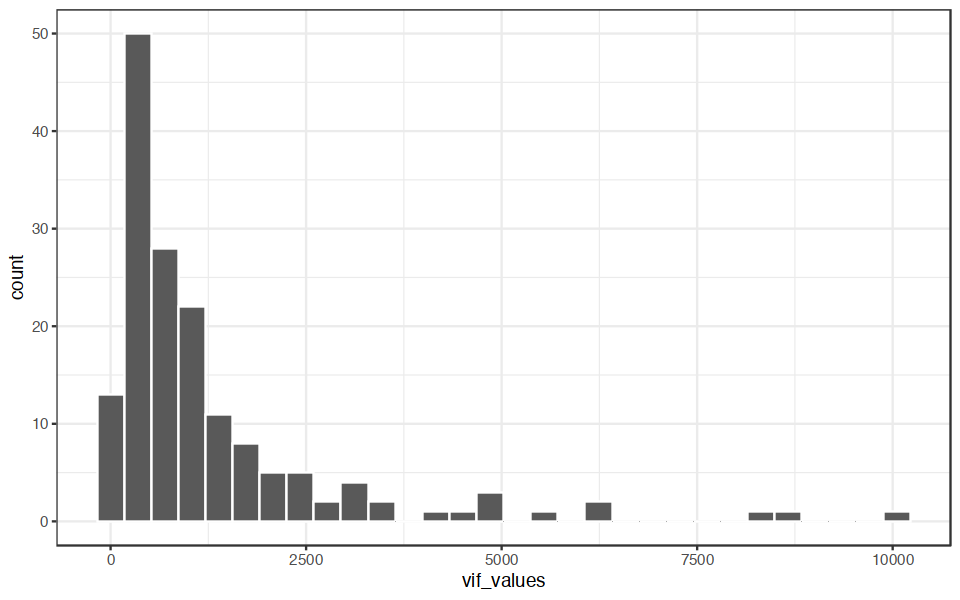

In [18]:
# Check the number of observations and events
total_obs <- nrow(became_data)
events <- sum(became_data$response_var == 1)

# Check EPV
predictor_count <- ncol(became_data) - 1  # Excluding the response variable
epv <- events / predictor_count

# Display results
cat("Total Observations:", total_obs, "\n")
cat("Events:", events, "\n")
cat("Predictors:", predictor_count, "\n")
cat("EPV:", epv, "\n")

# Check for multicollinearity using VIF
vif_values <- vif(glm(response_var ~ ., data = became_data, family = "binomial"))


# Display VIF values as histogram
options(repr.plot.width = 8, repr.plot.height = 5)

vif_values = data.frame(vif_values)
vif_values$lipid = rownames(vif_values)
cat("Minimum VIF:", min(vif_values$vif_values), "\n")
ggplot(vif_values,aes(vif_values))+
    geom_histogram(col='white')+
    theme_bw()

In [19]:
# became = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=1))
# miracle = data.frame(read_xlsx('../data/MIRACLE_LipidomicData_161LipidesCommuns.xlsx',sheet=1))
# 
# became_meta = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=2))
# miracle_meta = data.frame(read_xlsx('../data/MIRACLE_LipidomicData_161LipidesCommuns.xlsx',sheet=2))
# 
# became_num = became[,-c(1:7)]
# miracle_num = miracle[,-c(1:7)]
# 
# 
# became_tmp = became_meta[,c(1:3)]
# miracle_tmp = miracle_meta[,c(1:3)]
# colnames(became_tmp) = c('id','group','cluster')
# colnames(miracle_tmp) = c('id','group','cluster')
# 
# became_tmp$cluster = paste0('B',became_tmp$cluster)
# miracle_tmp$cluster = paste0('M',miracle_tmp$cluster)
# 
# became_tmp$cohort = 'BECAME'
# miracle_tmp$cohort = 'MIRACLE'
# 
# meta = rbind(became_tmp,miracle_tmp)
# rownames(meta) = paste0('X',meta$id)
# 
# for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}
# 
# 
# became_data = data.frame(t(log(became_num)))
# became_meta = became_tmp
# rownames(became_meta) = paste0('X',became_meta[,1])
# common = rownames(became_meta)[rownames(became_meta)%in%rownames(became_data)]
# 
# became_data = data.frame(scale(became_data[common,]))
# became_meta = became_meta[common,]
# response_name = 'group'
# became_data$response_var = as.factor(as.numeric(became_meta[rownames(became_data),response_name]=='HFpEF'))
# 

In [21]:
## Create Response Var

lipids = colnames(became_data)
became_data$response_var = as.factor(as.numeric(became_meta[rownames(became_data),'group']=='HFpEF'))


Start:  AIC=171.72
response_var ~ 1



Warning message in model.matrix.default(Terms, m, contrasts.arg = object$contrasts):
“the response appeared on the right-hand side and was dropped”
Warning message in model.matrix.default(Terms, m, contrasts.arg = object$contrasts):
“problem with term 162 in model.matrix: no columns are assigned”


       Df Deviance    AIC
+ X38   1   112.54 122.16
+ X77   1   117.37 127.00
+ X99   1   125.70 135.32
+ X81   1   127.29 136.91
+ X97   1   129.61 139.24
+ X4    1   130.84 140.46
+ X75   1   131.46 141.09
+ X78   1   132.93 142.56
+ X105  1   133.10 142.72
+ X94   1   134.40 144.03
+ X100  1   135.39 145.01
+ X104  1   136.82 146.44
+ X101  1   137.28 146.91
+ X61   1   138.02 147.64
+ X82   1   138.32 147.95
+ X80   1   139.07 148.70
+ X109  1   139.25 148.87
+ X79   1   139.77 149.40
+ X60   1   141.56 151.18
+ X98   1   141.74 151.37
+ X7    1   142.19 151.81
+ X83   1   142.87 152.50
+ X6    1   142.88 152.50
+ X1    1   142.89 152.51
+ X62   1   144.69 154.32
+ X103  1   145.71 155.34
+ X29   1   145.74 155.36
+ X88   1   146.23 155.85
+ X110  1   146.91 156.54
+ X3    1   147.14 156.77
+ X69   1   149.16 158.78
+ X108  1   149.68 159.31
+ X137  1   149.76 159.39
+ X5    1   149.97 159.59
+ X9    1   150.07 159.69
+ X84   1   151.54 161.17
+ X37   1   152.15 161.78
+ X90   1   

Warning message in model.matrix.default(Terms, m, contrasts.arg = object$contrasts):
“the response appeared on the right-hand side and was dropped”
Warning message in model.matrix.default(Terms, m, contrasts.arg = object$contrasts):
“problem with term 162 in model.matrix: no columns are assigned”


       Df Deviance     AIC
+ X77   1   59.859  74.296
+ X100  1   68.793  83.230
+ X99   1   72.296  86.733
+ X81   1   82.562  96.998
+ X108  1   83.534  97.971
+ X105  1   86.727 101.163
+ X101  1   88.497 102.934
+ X4    1   89.282 103.718
+ X109  1   89.354 103.790
+ X82   1   90.963 105.399
+ X97   1   91.449 105.885
+ X98   1   93.311 107.747
+ X61   1   94.226 108.662
+ X75   1   94.407 108.844
+ X95   1   94.467 108.904
+ X104  1   96.232 110.668
+ X83   1   96.282 110.718
+ X80   1   96.869 111.305
+ X94   1   97.600 112.037
+ X103  1   98.298 112.734
+ X151  1   98.323 112.760
+ X1    1   99.270 113.707
+ X78   1   99.513 113.950
+ X9    1   99.713 114.150
+ X84   1  100.100 114.536
+ X79   1  100.205 114.641
+ X111  1  100.455 114.892
+ X112  1  100.456 114.892
+ X107  1  101.480 115.917
+ X88   1  102.833 117.270
+ X87   1  103.235 117.672
+ X60   1  103.608 118.044
+ X42   1  103.745 118.182
+ X6    1  103.976 118.412
+ X3    1  104.523 118.960
+ X47   1  104.662 119.098
+

...


Step:  AIC=43.31
response_var ~ X38 + X77 + X100 + X87 + X18 + X4 + X2 + X89



Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message in model.matrix.default(Terms, m, contrasts.arg = object$contrasts):
“the response appeared on the right-hand side and was dropped”
Warning message in model.matrix.default(Terms, m, contrasts.arg = object$contrasts):
“problem with term 162 in model.matrix: no columns are assigned”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“gl

       Df Deviance     AIC
<none>       0.000  43.310
- X89   1    9.476  47.974
+ X94   1    0.000  48.122
+ X129  1    0.000  48.122
+ X6    1    0.000  48.122
+ X124  1    0.000  48.122
+ X106  1    0.000  48.122
+ X88   1    0.000  48.122
+ X39   1    0.000  48.122
+ X148  1    0.000  48.122
+ X103  1    0.000  48.122
+ X147  1    0.000  48.122
+ X131  1    0.000  48.122
+ X116  1    0.000  48.122
+ X125  1    0.000  48.122
+ X7    1    0.000  48.122
+ X120  1    0.000  48.122
+ X121  1    0.000  48.122
+ X91   1    0.000  48.122
+ X70   1    0.000  48.122
+ X161  1    0.000  48.122
+ X105  1    0.000  48.122
+ X69   1    0.000  48.122
+ X54   1    0.000  48.122
+ X23   1    0.000  48.122
+ X30   1    0.000  48.122
+ X137  1    0.000  48.122
+ X113  1    0.000  48.122
+ X41   1    0.000  48.122
+ X51   1    0.000  48.122
+ X159  1    0.000  48.122
+ X56   1    0.000  48.122
+ X123  1    0.000  48.122
+ X104  1    0.000  48.122
+ X17   1    0.000  48.122
+ X122  1    0.000  48.122
+


Call:
glm(formula = response_var ~ X38 + X77 + X100 + X87 + X18 + X4 + 
    X2 + X89, family = "binomial", data = train_data)

Deviance Residuals: 
       Min          1Q      Median          3Q         Max  
-1.499e-04  -2.100e-08   2.100e-08   2.100e-08   1.328e-04  

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)    91.29   16746.22   0.005    0.996
X38           263.30   39256.75   0.007    0.995
X77          -319.85   52842.69  -0.006    0.995
X100         -223.97   35913.02  -0.006    0.995
X87           108.28   20226.36   0.005    0.996
X18           130.31   20441.09   0.006    0.995
X4            125.68   23158.72   0.005    0.996
X2            -41.26    7498.46  -0.006    0.996
X89           -61.41   14112.44  -0.004    0.997

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1.6691e+02  on 122  degrees of freedom
Residual deviance: 9.4041e-08  on 114  degrees of freedom
AIC: 18

Number of Fisher Scoring iterations: 25


Setting levels: control = 0, case = 1

Setting direction: controls < cases



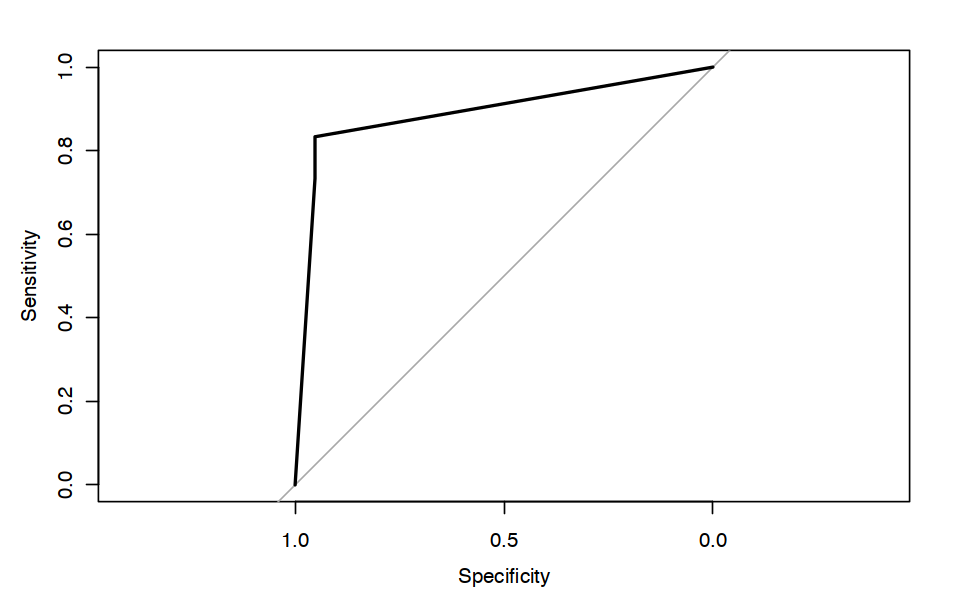

In [22]:

# Create a formula for the null model
null_model_formula <- as.formula(paste("response_var ~ 1"))
# Create a formula for lipids
lipids_formula <- as.formula(paste("response_var ~", paste(lipids, collapse = " + ")))


# Step 1: Split the data 
set.seed(123) # for reproducibility
index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)
train_data <- became_data[index,]
test_data <- became_data[-index,]

# Step 2: Forward-backward feature selection with BIC on lipids
null_model <- glm(null_model_formula, data = train_data, family = 'binomial')
lipids_model <- step(null_model, direction = "both", 
                     scope = list(lower = null_model_formula, upper = lipids_formula), 
                     k = log(nrow(train_data))) # trace=FALSE suppresses output

# Print out the selected lipid model
summary(lipids_model)


# Step 4: Evaluation of the final model with ROC and AUC
probabilities <- predict(lipids_model, newdata = test_data, type = "response")
roc_obj <- roc(test_data$response_var, probabilities)

# ROC curve
plot(roc_obj)

# AUC with 95% bootstrap confidence intervals
auc_value <- auc(roc_obj)
ci <- ci.auc(roc_obj, boot.n = 1000) # number of bootstraps

In [23]:
lipids_model


Call:  glm(formula = response_var ~ X38 + X77 + X100 + X87 + X18 + X4 + 
    X2 + X89, family = "binomial", data = train_data)

Coefficients:
(Intercept)          X38          X77         X100          X87          X18  
      91.29       263.30      -319.85      -223.97       108.28       130.31  
         X4           X2          X89  
     125.68       -41.26       -61.41  

Degrees of Freedom: 122 Total (i.e. Null);  114 Residual
Null Deviance:	    166.9 
Residual Deviance: 9.404e-08 	AIC: 18

In [24]:
table(data.frame(cbind(test_data$response_var,round(probabilities)+1)))

   X2
X1   1  2
  1 20  1
  2  6 24

In [25]:
became_data$cluster = became_meta$group
scaled_df_became = became_data[rownames(subset(meta,cohort=='BECAME')),]

In [26]:
ggplot(na.omit(scaled_df_became),aes(cluster,X39))+
    geom_point(position=position_jitter(width=.1))+
    geom_boxplot(alpha=.8,outlier.shape=NA)+theme_bw()+
    stat_compare_means()

ERROR: Error in stat_compare_means(): could not find function "stat_compare_means"


In [47]:
subset(lipid_meta,lipid_id_became=='PC(16:0_20:4(OH))')

,MeanDecreaseGini,lipid_id_became,lipid_id_miracle,lipid_class,modified_became_id
,<dbl>,<chr>,<chr>,<chr>,<chr>
X38,0.148962,PC(16:0_20:4(OH)),PC(16:0_20:4(OH)),Oxidized Phosphatidylcholines,PC(16:0_20:4(OH))


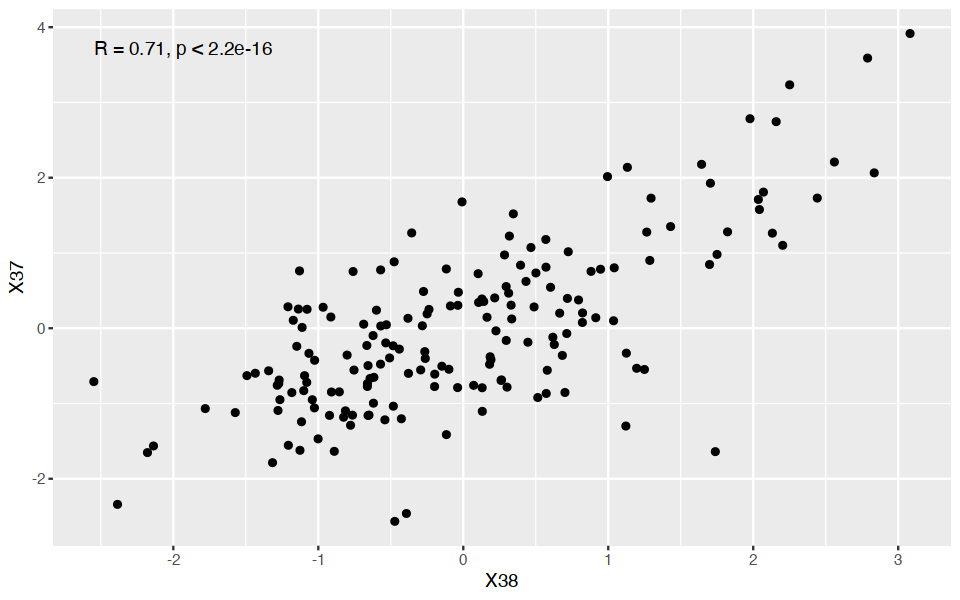

In [53]:
library(ggpubr)
ggplot(scaled_df_became,aes(X38,X37))+geom_point()+stat_cor()